## Step 1: Load the snapshot

In [1]:
import pandas as pd

# ============================================
# LOAD YFINANCE DATA - LAST YEAR ONLY
# ============================================

# Load full yfinance dataset
df_full = pd.read_csv(
    "../data/raw/crypto_yfinance_raw.csv",
    parse_dates=["timestamp"]
)

print(f"Full dataset shape: {df_full.shape}")
print(f"Date range: {df_full['timestamp'].min().date()} → "
      f"{df_full['timestamp'].max().date()}")

# ── Filter last year only ──
one_year_ago = df_full["timestamp"].max() - pd.DateOffset(years=1)

df = df_full[df_full["timestamp"] >= one_year_ago].copy()
df = df.sort_values(["coin", "timestamp"]).reset_index(drop=True)

print(f"\n✅ Filtered to last year:")
print(f"   Shape: {df.shape}")
print(f"   Date range: {df['timestamp'].min().date()} → "
      f"{df['timestamp'].max().date()}")
print(f"   Rows per coin:")
print(f"   {df['coin'].value_counts().to_dict()}")

df.head()


Full dataset shape: (6344, 4)
Date range: 2017-01-01 → 2026-02-10

✅ Filtered to last year:
   Shape: (732, 4)
   Date range: 2025-02-10 → 2026-02-10
   Rows per coin:
   {'btc': 366, 'eth': 366}


,timestamp,price,volume,coin
0,2025-02-10,97437.554688,40078962391,btc
1,2025-02-11,95747.429688,37488783272,btc
2,2025-02-12,97885.859375,49340445530,btc
3,2025-02-13,96623.867188,37147280860,btc
4,2025-02-14,97508.968750,32697987277,btc


## Step 2: check the data 

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  732 non-null    datetime64[ns]
 1   price      732 non-null    float64       
 2   volume     732 non-null    int64         
 3   coin       732 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 23.0+ KB


In [3]:
df.shape


(732, 4)

In [4]:
#check the missing values 
(df.isnull().sum())

timestamp    0
price        0
volume       0
coin         0
dtype: int64

In [5]:
#check duplicates 
(df.duplicated().sum())

np.int64(0)

In [6]:
#data type check 
(df.dtypes)

timestamp    datetime64[ns]
price               float64
volume                int64
coin                 object
dtype: object

In [7]:
#identify which columns are likely categorical
(df.nunique())

timestamp    366
price        732
volume       732
coin           2
dtype: int64

## Step 3: Data preprocessing 

In [8]:
# round the values 
df["price"] = df["price"].round(2)
df["volume"] = df["volume"].round(0)

In [11]:
df = df.sort_values(["coin", "timestamp"]).reset_index(drop=True)
df.head()

,timestamp,price,volume,coin
0,2025-02-10,97437.55,40078962391,btc
1,2025-02-11,95747.43,37488783272,btc
2,2025-02-12,97885.86,49340445530,btc
3,2025-02-13,96623.87,37147280860,btc
4,2025-02-14,97508.97,32697987277,btc


## Step 4: Feature engineering 

* We will create a new feature that measures change in price from one day to the next, providing insights into the coin's daily performance and volatility​​ 
- log returns= ln(Price today/Price yesterday)
- this feature will replace the price_change_24h and price_change_percentage_24h features which are snapshot values and remain constant across the historical dataset.


In [12]:
import numpy as np

df = df.sort_values(["coin", "timestamp"])

df["log_return_1d"] = (
    df.groupby("coin")["price"]
    .transform(lambda x: np.log(x / x.shift(1)))
)


* we will create a new feature to mesure the rolling risk of the coin in a given period (7 days, 14 days) 
So instead of just knowing today s return, we know how unstable or risky the coin is in the last period. 


In [13]:
df["volatility_7d"] = (
    df.groupby("coin")["log_return_1d"]
    .rolling(window=7)
    .std()
    .reset_index(level=0, drop=True)
)

df["volatility_14d"] = (
    df.groupby("coin")["log_return_1d"]
    .rolling(window=14)
    .std()
    .reset_index(level=0, drop=True)
)

* we will create a new feature for the RSI 14 day (relative strength index) which evaluates the overbought or oversold condition of a coin base on its recent price movements

In [14]:
window = 14

delta = df.groupby("coin")["price"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.groupby(df["coin"]).rolling(window).mean().reset_index(level=0, drop=True)
avg_loss = loss.groupby(df["coin"]).rolling(window).mean().reset_index(level=0, drop=True)

rs = avg_gain / avg_loss
df["rsi_14"] = 100 - (100 / (1 + rs))


* Rolling features such as volatility and RSI require a historical window of 7–14 days. The 14 first rows per coin do not have sufficient data to compute these indicators and will contain Nan values . instead of dropping the rows we will fill them as we have a small dataset and we don't want to lose data . 

In [15]:
# FILL NaNs STRATEGY (instead of dropping rows)

# Strategy for volatility: Fill with 0 (no volatility calculated yet)
df["volatility_7d"] = df["volatility_7d"].fillna(0)
df["volatility_14d"] = df["volatility_14d"].fillna(0)

# Strategy for RSI: Fill with 50 (neutral RSI - neither overbought nor oversold)
df["rsi_14"] = df["rsi_14"].fillna(50)

# Verify no NaNs remain in these features
print("NaNs filled successfully!")
print(f"Total rows retained: {len(df)}")
print("\nNaN count per column:")
print(df[["volatility_7d", "volatility_14d", "rsi_14"]].isna().sum())

# Check first 20 rows to see filled values
print("\nFirst 20 rows (should see filled values):")
print(df[["timestamp", "coin", "volatility_7d", "volatility_14d", "rsi_14"]].head(20))

NaNs filled successfully!
Total rows retained: 732

NaN count per column:
volatility_7d     0
volatility_14d    0
rsi_14            0
dtype: int64

First 20 rows (should see filled values):
    timestamp coin  volatility_7d  volatility_14d     rsi_14
0  2025-02-10  btc       0.000000        0.000000  50.000000
1  2025-02-11  btc       0.000000        0.000000  50.000000
2  2025-02-12  btc       0.000000        0.000000  50.000000
3  2025-02-13  btc       0.000000        0.000000  50.000000
4  2025-02-14  btc       0.000000        0.000000  50.000000
5  2025-02-15  btc       0.000000        0.000000  50.000000
6  2025-02-16  btc       0.000000        0.000000  50.000000
7  2025-02-17  btc       0.014328        0.000000  50.000000
8  2025-02-18  btc       0.012736        0.000000  50.000000
9  2025-02-19  btc       0.009937        0.000000  50.000000
10 2025-02-20  btc       0.010857        0.000000  50.000000
11 2025-02-21  btc       0.013874        0.000000  50.000000
12 2025-02-22  bt

In [16]:
pd.set_option('display.max_columns', None)
df.head()

,timestamp,price,volume,coin,log_return_1d,volatility_7d,volatility_14d,rsi_14
0,2025-02-10,97437.55,40078962391,btc,NaN,0.0,0.0,50.0
1,2025-02-11,95747.43,37488783272,btc,-0.017498,0.0,0.0,50.0
2,2025-02-12,97885.86,49340445530,btc,0.022088,0.0,0.0,50.0
3,2025-02-13,96623.87,37147280860,btc,-0.012976,0.0,0.0,50.0
4,2025-02-14,97508.97,32697987277,btc,0.009119,0.0,0.0,50.0


 - we will add a new feature fo the Moving averages that smooths out price data by taking the average price over a set period of time 
 - short term MA Tracks short-term momentum, reacts quickly to price changes. Good for:short-term signals,detecting quick trend shifts
 - Medium term MA Smoother than MA7 Confirms trends that last longer than just a few days. Often used with MA7 to detect crossovers. if MA7 crossing above MA14 → bullish momentum. if MA7 crossing below MA14 → bearish momentum
 - long term MA Identifies the overall market direction.if price above MA30 → long-term bullish bias. if price below MA30 → long-term bearish bias
 - Price relative to MA7 (normalized) gives the percentage distance between price and MA7 or MA30 indicating . if large positive → possibly overbought. if arge negative → possibly oversold

- as we have rolling features that requires a historical window of 30 days we will have Nan's in the first row these not be dropped as we already have a small dataset insted we will fill them with the current price value 

In [17]:
# MAs 
df["ma_7"] = df.groupby("coin")["price"].rolling(7).mean().reset_index(level=0, drop=True)
df["ma_14"] = df.groupby("coin")["price"].rolling(14).mean().reset_index(level=0, drop=True)
df["ma_30"] = df.groupby("coin")["price"].rolling(30).mean().reset_index(level=0, drop=True)

# FILL NaNs with current price (assumes no trend yet)
df["ma_7"] = df["ma_7"].fillna(df["price"])
df["ma_14"] = df["ma_14"].fillna(df["price"])
df["ma_30"] = df["ma_30"].fillna(df["price"])

# Price relative to MA (normalized)
df["price_to_ma7"] = (df["price"] - df["ma_7"]) / df["ma_7"]
df["price_to_ma30"] = (df["price"] - df["ma_30"]) / df["ma_30"]

# These will naturally be 0 where MAs were filled with price
df["price_to_ma7"] = df["price_to_ma7"].fillna(0)
df["price_to_ma30"] = df["price_to_ma30"].fillna(0)

print(" Moving Averages added (no NaNs)!")
print(f"Total rows: {len(df)}")
print(df[["timestamp", "coin", "price", "ma_7", "ma_14", "ma_30", "price_to_ma7", "price_to_ma30"]].head(35)) 

 Moving Averages added (no NaNs)!
Total rows: 732
    timestamp coin     price          ma_7         ma_14         ma_30  \
0  2025-02-10  btc  97437.55  97437.550000  97437.550000  97437.550000   
1  2025-02-11  btc  95747.43  95747.430000  95747.430000  95747.430000   
2  2025-02-12  btc  97885.86  97885.860000  97885.860000  97885.860000   
3  2025-02-13  btc  96623.87  96623.870000  96623.870000  96623.870000   
4  2025-02-14  btc  97508.97  97508.970000  97508.970000  97508.970000   
5  2025-02-15  btc  97580.35  97580.350000  97580.350000  97580.350000   
6  2025-02-16  btc  96175.03  96994.151429  96175.030000  96175.030000   
7  2025-02-17  btc  95773.38  96756.412857  95773.380000  95773.380000   
8  2025-02-18  btc  95539.55  96726.715714  95539.550000  95539.550000   
9  2025-02-19  btc  96635.61  96548.108571  96635.610000  96635.610000   
10 2025-02-20  btc  98333.94  96792.404286  98333.940000  98333.940000   
11 2025-02-21  btc  96125.55  96594.772857  96125.550000  9612

- we will create a new feature MACD (Moving average convergence divergence) : 
- calculates an Exponential Moving Averages (EMA 12 → fast / short-term momentum, EMA 26 → slow / longer-term momentum)
- Measures the distance between fast and slow momentum and shows who is in control buyers or sellers , higher MACD → strong upward momentum, lower MACD → strong downward momentum
- calculates the signal which is the EMA of the MACD line ( EMA 9) and shows the smoothed momentum trend
- calculates the histogram which is the difference between the MACD line and the signal line and shows the momentum strength and potential reversals ( positive histogram → bullish momentum, negative histogram → bearish momentum)


In [18]:
# MACD INDICATORS
# Calculate EMA 12 and EMA 26
ema_12 = df.groupby("coin")["price"].ewm(span=12, adjust=False).mean().reset_index(level=0, drop=True)
ema_26 = df.groupby("coin")["price"].ewm(span=26, adjust=False).mean().reset_index(level=0, drop=True)

# MACD Line = EMA12 - EMA26
df["macd"] = ema_12 - ema_26

# Signal Line = EMA(9) of MACD
df["macd_signal"] = df.groupby("coin")["macd"].ewm(span=9, adjust=False).mean().reset_index(level=0, drop=True)

# MACD Histogram = MACD - Signal (momentum strength)
df["macd_histogram"] = df["macd"] - df["macd_signal"]

print("MACD indicators added!")

MACD indicators added!


In [19]:
# Fill NaNs (first few rows won't have MACD calculated)
# Strategy: Fill with 0 (no momentum signal yet)
df["macd"] = df["macd"].fillna(0)
df["macd_signal"] = df["macd_signal"].fillna(0)
df["macd_histogram"] = df["macd_histogram"].fillna(0)

print("MACD indicators added (no NaNs)!")
print(f"Total rows: {len(df)}")
print("\nFirst 30 rows to verify:")
print(df[["timestamp", "coin", "price", "macd", "macd_signal", "macd_histogram"]].head(30))
print("\nLast 10 rows:")
print(df[["timestamp", "coin", "price", "macd", "macd_signal", "macd_histogram"]].tail(10))

MACD indicators added (no NaNs)!
Total rows: 732

First 30 rows to verify:
    timestamp coin     price         macd  macd_signal  macd_histogram
0  2025-02-10  btc  97437.55     0.000000     0.000000        0.000000
1  2025-02-11  btc  95747.43  -134.824387   -26.964877     -107.859510
2  2025-02-12  btc  97885.86   -68.332561   -35.238414      -33.094147
3  2025-02-13  btc  96623.87  -116.130674   -51.416866      -64.713808
4  2025-02-14  btc  97508.97   -81.649643   -57.463422      -24.186222
5  2025-02-15  btc  97580.35   -48.009980   -55.572733        7.562754
6  2025-02-16  btc  96175.03  -133.212295   -71.100646      -62.111649
7  2025-02-17  btc  95773.38  -230.488612  -102.978239     -127.510373
8  2025-02-18  btc  95539.55  -322.728706  -146.928332     -175.800374
9  2025-02-19  btc  96635.61  -303.883780  -178.319422     -125.564358
10 2025-02-20  btc  98333.94  -150.176857  -172.690909       22.514052
11 2025-02-21  btc  96125.55  -204.207652  -178.994257      -25.213394
12

- We will add a new feature Momentum Indicator that Measures how fast price is moving 

In [20]:
# 5-day momentum (short-term velocity)
df["momentum_5d"] = df.groupby("coin")["price"].pct_change(periods=5)

# 10-day momentum (medium-term velocity)
df["momentum_10d"] = df.groupby("coin")["price"].pct_change(periods=10)

# Momentum acceleration (difference between short and medium term)
df["momentum_acceleration"] = df["momentum_5d"] - df["momentum_10d"]


In [21]:
# Fill NaNs (first 10 rows won't have 10d momentum)
# Strategy: Fill with 0 (no momentum calculated yet)
df["momentum_5d"] = df["momentum_5d"].fillna(0)
df["momentum_10d"] = df["momentum_10d"].fillna(0)
df["momentum_acceleration"] = df["momentum_acceleration"].fillna(0)

print("Momentum indicators added (no NaNs)!")
print(f"Total rows: {len(df)}")
print("\nFirst 15 rows to verify:")
print(df[["timestamp", "coin", "price", "momentum_5d", "momentum_10d", "momentum_acceleration"]].head(15))
print("\nRows around Feb crash (14-25):")
print(df[["timestamp", "coin", "price", "momentum_5d", "momentum_10d", "momentum_acceleration"]].iloc[13:26])

Momentum indicators added (no NaNs)!
Total rows: 732

First 15 rows to verify:
    timestamp coin     price  momentum_5d  momentum_10d  momentum_acceleration
0  2025-02-10  btc  97437.55     0.000000      0.000000               0.000000
1  2025-02-11  btc  95747.43     0.000000      0.000000               0.000000
2  2025-02-12  btc  97885.86     0.000000      0.000000               0.000000
3  2025-02-13  btc  96623.87     0.000000      0.000000               0.000000
4  2025-02-14  btc  97508.97     0.000000      0.000000               0.000000
5  2025-02-15  btc  97580.35     0.001466      0.000000               0.000000
6  2025-02-16  btc  96175.03     0.004466      0.000000               0.000000
7  2025-02-17  btc  95773.38    -0.021581      0.000000               0.000000
8  2025-02-18  btc  95539.55    -0.011222      0.000000               0.000000
9  2025-02-19  btc  96635.61    -0.008957      0.000000               0.000000
10 2025-02-20  btc  98333.94     0.007723      0.009

## Step 5: EDA and visualization 

this EDA section should help us answer:

* What does price actually look like over time?

* Which features move with price vs against it?

* Which features are redundant?

* Which features are informative for short-term prediction (LSTM)?

* Are there regime effects? (bull vs bear signals)

since it's a time series data we will care more about:

* relationships over time

* relative changes

* leading indicators

In [22]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   timestamp              732 non-null    datetime64[ns]
 1   price                  732 non-null    float64       
 2   volume                 732 non-null    int64         
 3   coin                   732 non-null    object        
 4   log_return_1d          730 non-null    float64       
 5   volatility_7d          732 non-null    float64       
 6   volatility_14d         732 non-null    float64       
 7   rsi_14                 732 non-null    float64       
 8   ma_7                   732 non-null    float64       
 9   ma_14                  732 non-null    float64       
 10  ma_30                  732 non-null    float64       
 11  price_to_ma7           732 non-null    float64       
 12  price_to_ma30          732 non-null    float64       
 13  macd 

,count,mean,min,25%,50%,75%,max,std
timestamp,732,2025-08-11 12:00:00.000000256,2025-02-10 00:00:00,2025-05-12 00:00:00,2025-08-11 12:00:00,2025-11-11 00:00:00,2026-02-10 00:00:00,NaN
price,732.0,51567.06168,1472.55,2953.1225,33766.725,102263.5875,124752.53,49446.520893
volume,732.0,40373391156.554642,6117036512.0,22423769856.5,36757596099.0,53087639660.25,181746419401.0,23102410677.466797
log_return_1d,730.0,-0.000855,-0.162681,-0.01564,-0.000188,0.012639,0.197196,0.033419
volatility_7d,732.0,0.028004,0.0,0.0159,0.023764,0.034359,0.093492,0.01759
volatility_14d,732.0,0.028226,0.0,0.017813,0.025788,0.035809,0.07081,0.015055
rsi_14,732.0,50.636231,12.305703,37.236881,49.727277,61.897098,98.801907,17.134979
ma_7,732.0,51684.03863,1572.251429,2945.407143,36936.407857,103018.551429,122781.401429,49491.335235
ma_14,732.0,51797.198163,1584.025,2968.176786,39841.764643,101310.952143,119094.227857,49537.317593
ma_30,732.0,51769.717316,1684.383667,3022.57775,41505.294833,101081.208167,117506.825667,49483.081097


In [23]:
df.shape

(732, 19)

In [25]:
df.head()

,timestamp,price,volume,coin,log_return_1d,volatility_7d,volatility_14d,rsi_14,ma_7,ma_14,ma_30,price_to_ma7,price_to_ma30,macd,macd_signal,macd_histogram,momentum_5d,momentum_10d,momentum_acceleration,time_diff
0,2025-02-10,97437.55,40078962391,btc,NaN,0.0,0.0,50.0,97437.55,97437.55,97437.55,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,NaT
1,2025-02-11,95747.43,37488783272,btc,-0.017498,0.0,0.0,50.0,95747.43,95747.43,95747.43,0.0,0.0,-134.824387,-26.964877,-107.859510,0.0,0.0,0.0,1 days
2,2025-02-12,97885.86,49340445530,btc,0.022088,0.0,0.0,50.0,97885.86,97885.86,97885.86,0.0,0.0,-68.332561,-35.238414,-33.094147,0.0,0.0,0.0,1 days
3,2025-02-13,96623.87,37147280860,btc,-0.012976,0.0,0.0,50.0,96623.87,96623.87,96623.87,0.0,0.0,-116.130674,-51.416866,-64.713808,0.0,0.0,0.0,1 days
4,2025-02-14,97508.97,32697987277,btc,0.009119,0.0,0.0,50.0,97508.97,97508.97,97508.97,0.0,0.0,-81.649643,-57.463422,-24.186222,0.0,0.0,0.0,1 days


In [26]:
# Basic statistics per coin
basic_stats = df.groupby("coin")[["price", "volume", 
                                  "log_return_1d", "volatility_7d", "rsi_14"]].describe()
print(basic_stats)


      price                                                                 \
      count           mean           std       min         25%         50%   
coin                                                                         
btc   366.0  100108.181940  13055.824483  62702.10  88522.9525  102269.765   
eth   366.0    3025.941421    877.041616   1472.55   2439.1050    2952.985   

                            volume                                            \
             75%        max  count          mean           std           min   
coin                                                                           
btc   110977.410  124752.53  366.0  5.234816e+10  2.378721e+10  9.863214e+09   
eth     3762.395    4831.35  366.0  2.839862e+10  1.467985e+10  6.117037e+09   

                                                             log_return_1d  \
               25%           50%           75%           max         count   
coin                                                

** Price :

Bitcoin: Mean ≈ 100,955 USD, Std ≈ 12,367, Min ≈ 76,329, Max ≈ 124,774
Ethereum: Mean ≈ 3,056 USD, Std ≈ 880, Min ≈ 1,471, Max ≈ 4,829 

- Bitcoin is roughly 33x more expensive than Ethereum -> large scale difference → we will need normalization before feeding to ML/LSTM.


** Market cap: 

Bitcoin: Mean ≈ 2.01T, Std ≈ 0.25T, Max ≈ 2.21T
Ethereum: Mean ≈ 0.37T, Std ≈ 0.11T, Max ≈ 0.46T
- Bitcoin dominates market cap as expected (~5x Ethereum) and the std deviation relative to the mean shows Ethereum is more volatile

** RSI 14 day:

Mean ≈ 51 for both coins → roughly neutral (50 is the midpoint).
Max Bitcoin ≈ 88, Max Ethereum ≈ 99 → Ethereum can get extremely overbought.
Min Bitcoin ≈ 16, Min Ethereum ≈ 15 → Both can get oversold.

- RSI shows both coins reach extremes, but Ethereum more often hits the very high/low zones could signal strong trend moves

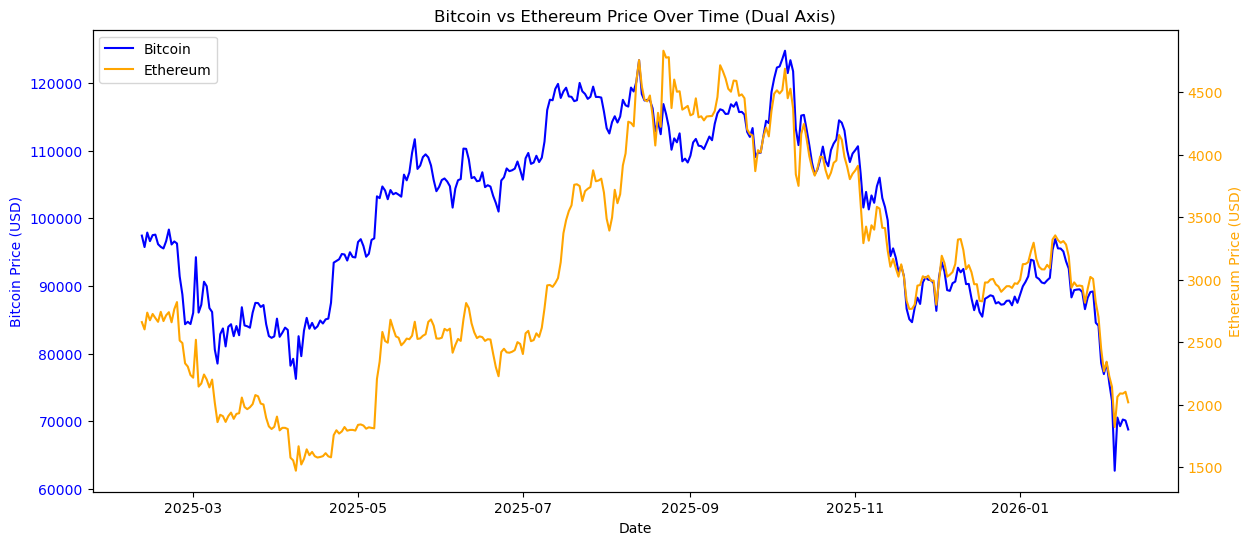

In [28]:
import matplotlib.pyplot as plt
#price over time 
plt.figure(figsize=(14,6))

# Separate data
btc = df[df['coin'] == 'btc']
eth = df[df['coin'] == 'eth']

# Plot Bitcoin
ax = plt.gca()
ax.plot(btc['timestamp'], btc['price'], color='blue', label='Bitcoin')
ax.set_ylabel('Bitcoin Price (USD)', color='blue')
ax.tick_params(axis='y', labelcolor='blue')

# Plot Ethereum on secondary axis
ax2 = ax.twinx()
ax2.plot(eth['timestamp'], eth['price'], color='orange', label='Ethereum')
ax2.set_ylabel('Ethereum Price (USD)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title("Bitcoin vs Ethereum Price Over Time (Dual Axis)")
ax.set_xlabel("Date")

# Legends
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()



- Co-movement: Many price spikes in Bitcoin coincide with similar spikes in Ethereum suggesting a correlation between the two coins, likely due to market sentiment and shared investor base (btc movement could serve as a predictive feature for Ethereum in ML models and vice versa)
- Volatility: Ethereum's price appears more jagged compared to Bitcoin confirming its higher volatility



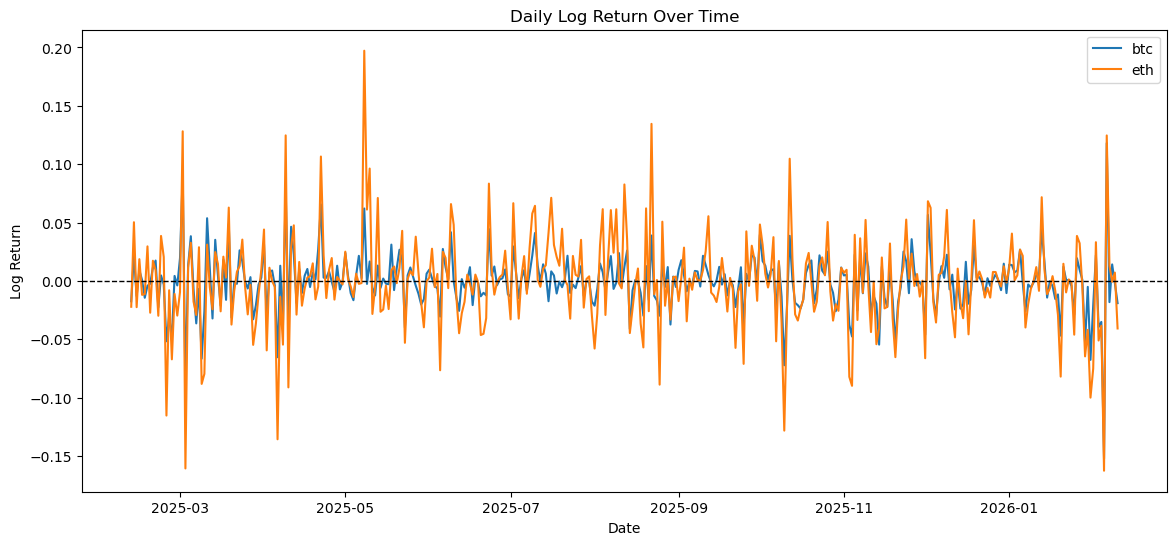

In [29]:
# Daily Log Return Over Time

plt.figure(figsize=(14,6))

for coin in df['coin'].unique():
    coin_df = df[df['coin'] == coin]
    plt.plot(coin_df['timestamp'], coin_df['log_return_1d'], label=coin)

plt.axhline(0, color='black', linestyle='--', linewidth=1)  # zero line
plt.title("Daily Log Return Over Time")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend()
plt.show()


- Log Return:

Ethereum shows larger daily swings (both positive and negative) compared to Bitcoin, confirming higher daily volatility.
Spikes indicate sudden market movements potential risk periods or trading opportunities.

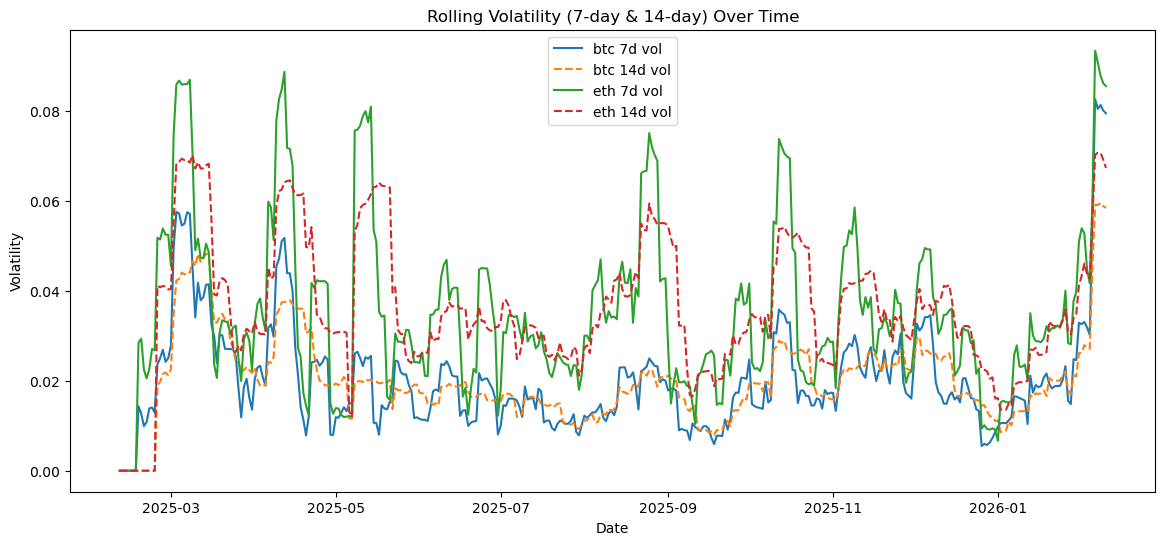

In [30]:
# Rolling Volatility Over Time

plt.figure(figsize=(14,6))

for coin in df['coin'].unique():
    coin_df = df[df['coin'] == coin]
    plt.plot(coin_df['timestamp'], coin_df['volatility_7d'], label=f'{coin} 7d vol')
    plt.plot(coin_df['timestamp'], coin_df['volatility_14d'], label=f'{coin} 14d vol', linestyle='--')  # <- add # for comment

plt.title("Rolling Volatility (7-day & 14-day) Over Time")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()

- Rolling Volatility:

Bitcoin’s rolling volatility is relatively stable, Ethereum’s volatility fluctuates more widely.
7day vs 14day: shorter windows capture quick spikes, longer windows smooth the noise and show trend volatility
Log returns and rolling volatility are key inputs for LSTM models because they represent normalized price movement and risk dynamics..

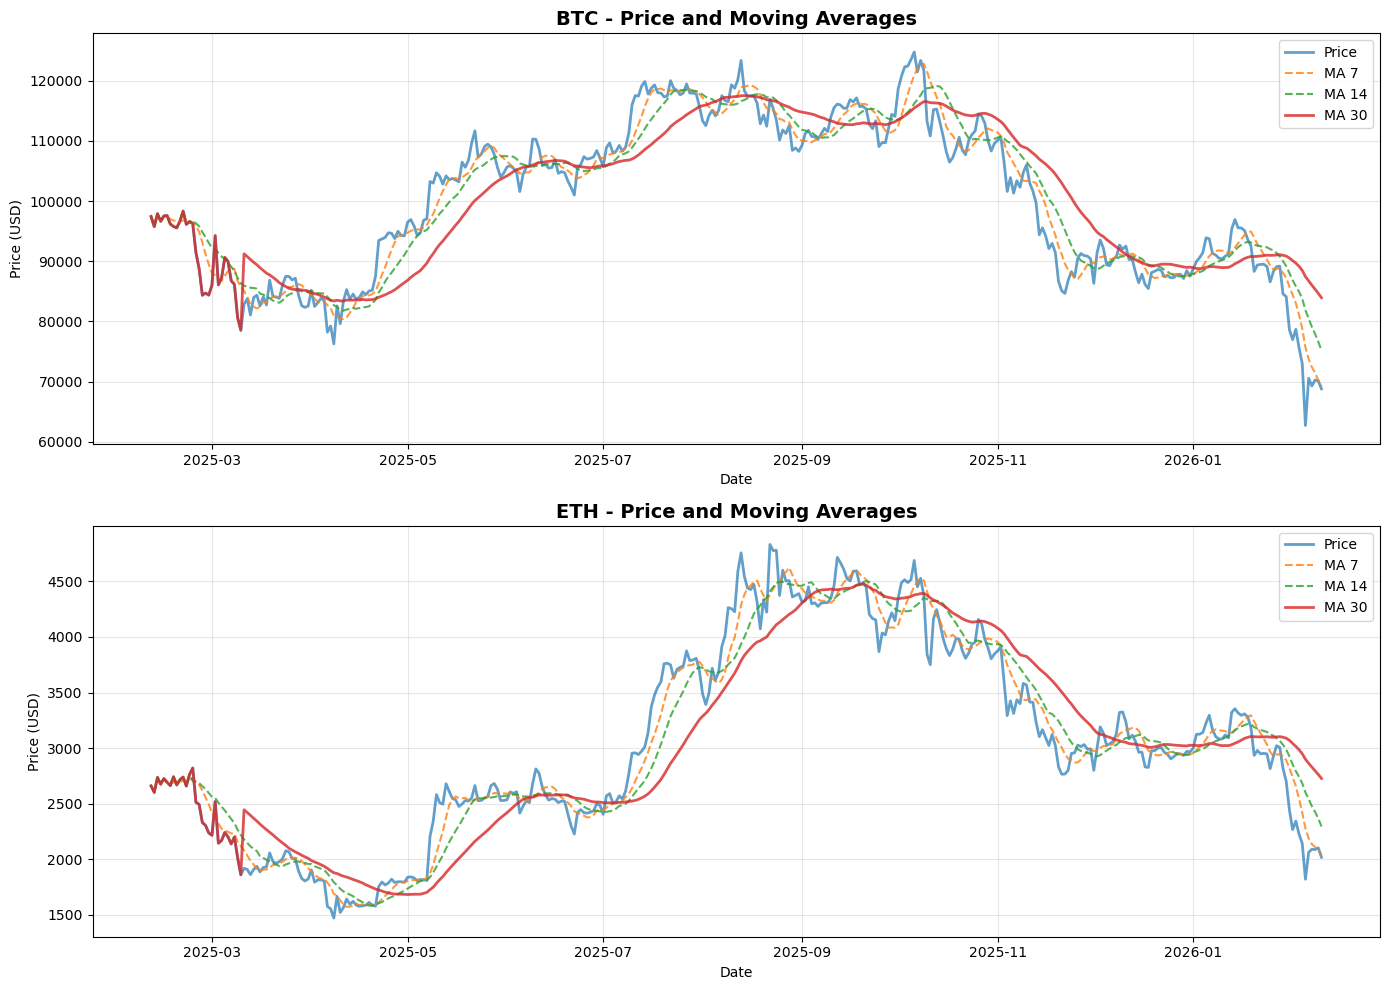

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1: Price + Moving Averages
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for idx, coin_name in enumerate(["btc", "eth"]):
    coin_data = df[df["coin"] == coin_name].copy()
    
    ax = axes[idx]
    ax.plot(coin_data["timestamp"], coin_data["price"], label="Price", linewidth=2, alpha=0.7)
    ax.plot(coin_data["timestamp"], coin_data["ma_7"], label="MA 7", linestyle="--", alpha=0.8)
    ax.plot(coin_data["timestamp"], coin_data["ma_14"], label="MA 14", linestyle="--", alpha=0.8)
    ax.plot(coin_data["timestamp"], coin_data["ma_30"], label="MA 30", linestyle="-", linewidth=2, alpha=0.8)
    
    ax.set_title(f"{coin_name.upper()} - Price and Moving Averages", fontsize=14, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (USD)")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

- MA30 (long-term) → Smoothest, shows overall trend direction
- MA14 (medium-term) → Less smooth, reacts faster to changes
- MA7 (short-term) → Captures short-term volatility and price swings

1. MA Crossovers: 
- MA7 crosses above MA30 → Bullish signal (uptrend starting)
- MA7 crosses below MA30 → Bearish signal (downtrend starting)

2. Price Position Relative to MAs, When price is:
- Above all MAs → Strong uptrend, bullish momentum
- Below all MAs → Strong downtrend, bearish momentum
- Between MAs → Transition/consolidation phase, uncertainty

3. MA Spread (Distance Between MAs)
- Wide spread (MA7 far from MA30) → Strong trend (up or down)
- Narrow spread (MAs converging) → Weak trend, possible reversal coming

4. Support/Resistance Levels , MAs often act as:
- Support during uptrends (price bounces off MA30)
- Resistance during downtrends (price struggles to cross above MA30)

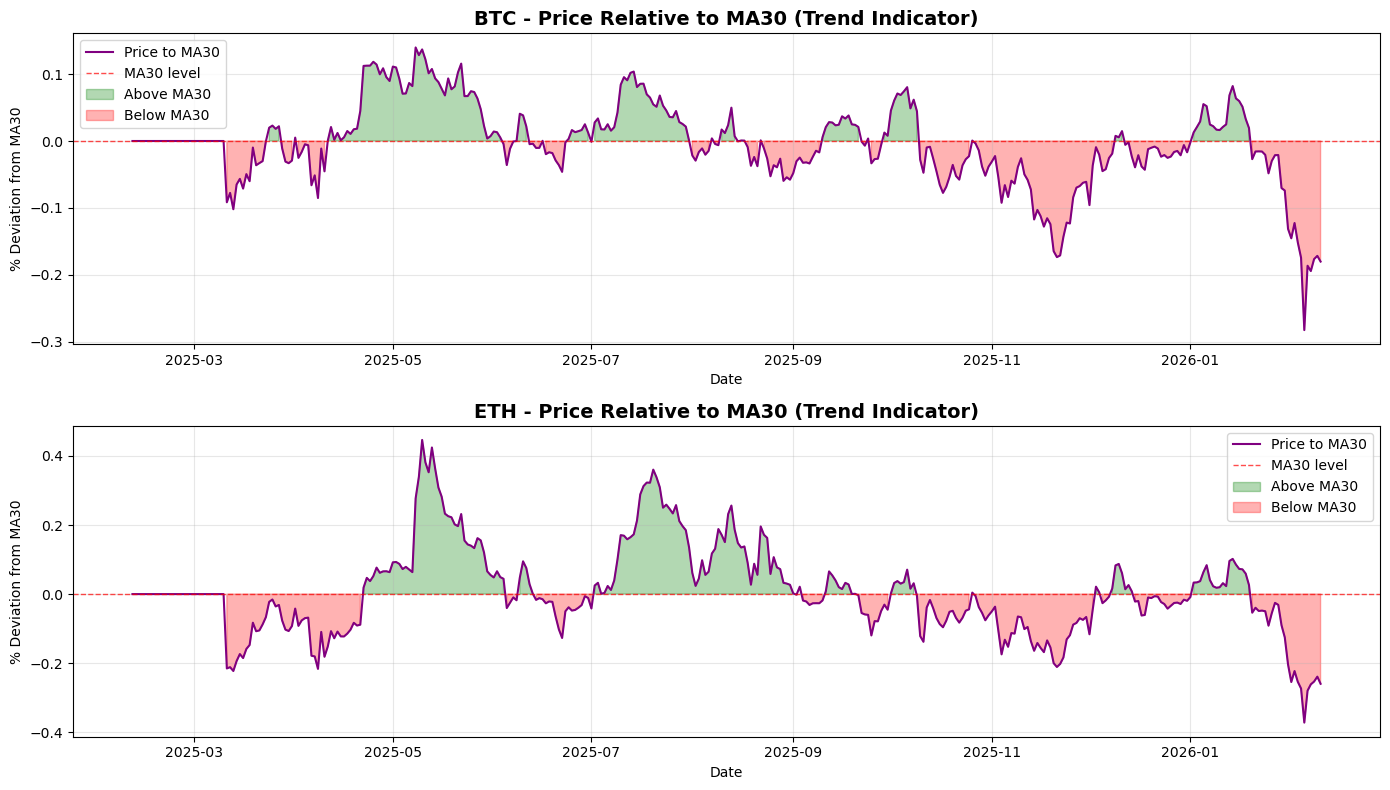

In [33]:
# Plot 2: Price relative to MA30 (shows when price is above/below long-term trend)
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for idx, coin_name in enumerate(["btc", "eth"]):
    coin_data = df[df["coin"] == coin_name].copy()
    
    ax = axes[idx]
    ax.plot(coin_data["timestamp"], coin_data["price_to_ma30"], label="Price to MA30", color="purple")
    ax.axhline(0, color="red", linestyle="--", linewidth=1, alpha=0.7, label="MA30 level")
    ax.fill_between(coin_data["timestamp"], 0, coin_data["price_to_ma30"], 
                     where=(coin_data["price_to_ma30"] > 0), color="green", alpha=0.3, label="Above MA30")
    ax.fill_between(coin_data["timestamp"], 0, coin_data["price_to_ma30"], 
                     where=(coin_data["price_to_ma30"] < 0), color="red", alpha=0.3, label="Below MA30")
    
    ax.set_title(f"{coin_name.upper()} - Price Relative to MA30 (Trend Indicator)", fontsize=14, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("% Deviation from MA30")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

1. Lag Effect

- MA30 lags behind price movements during crashes, MA30 stays high while price drops → creates the gap in price relative to MA30 
- % deviation from 30-day trend: Green zone = price above trend (bullish) there is probability of bounce back
- % deviation from 30-day trend:Red zone = price below trend (bearish) there is probability of pull back
- When very negative (-0.20) → Bounce back happens → Mean reversion


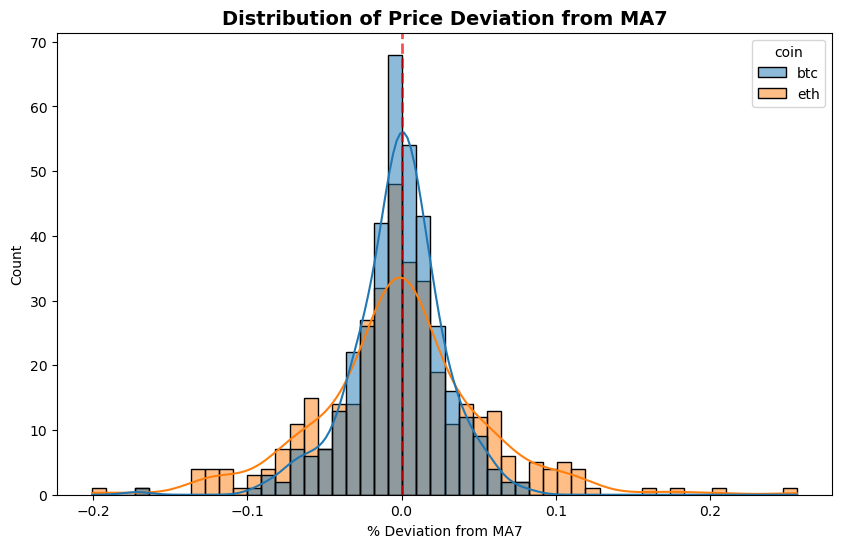

In [34]:
# Plot 3: Distribution of price_to_ma7 (useful for modeling)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.histplot(data=df, x="price_to_ma7", hue="coin", bins=50, kde=True, ax=ax)
ax.set_title("Distribution of Price Deviation from MA7", fontsize=14, fontweight="bold")
ax.set_xlabel("% Deviation from MA7")
ax.axvline(0, color="red", linestyle="--", linewidth=2, alpha=0.7)
plt.show()

1. Distribution of price_to_ma7 shows:How often price is above/below its 7-day average
- Price is above MA7 ~ 50% of the time for both coins, indicating a balance between bullish and bearish periods.
- No extreme skew → good for our model, won't be biased toward always predicting up or down

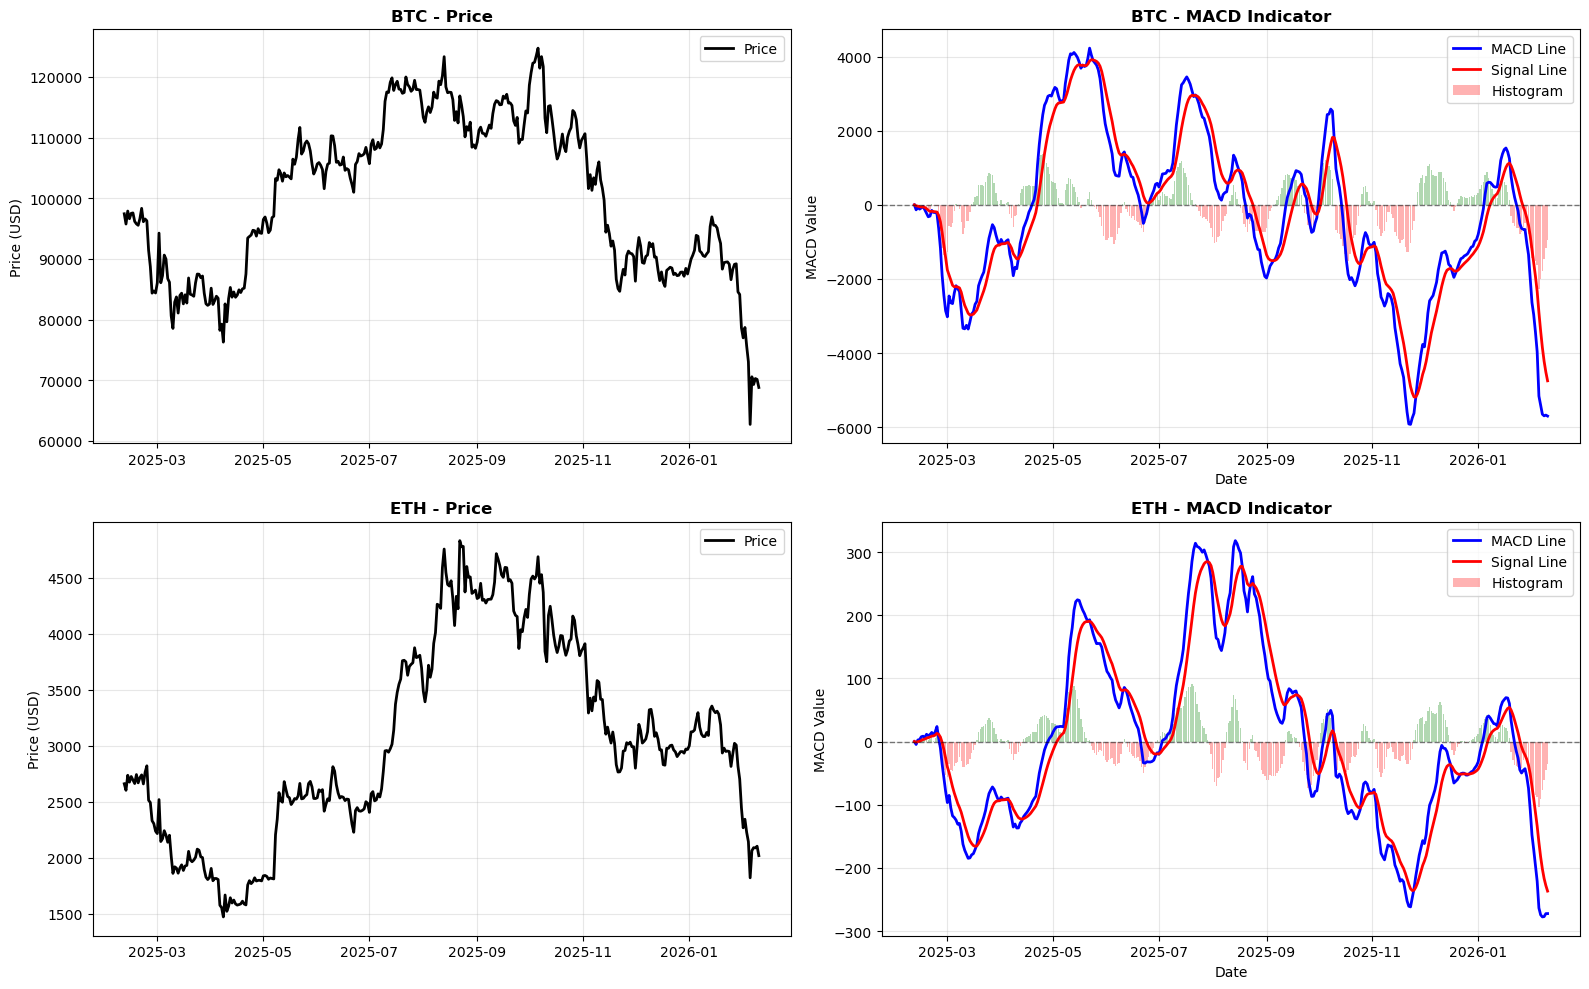

In [35]:
# EDA: MACD INDICATORS
# Plot 1: MACD Line, Signal Line, and Histogram
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, coin_name in enumerate(["btc", "eth"]):
    coin_data = df[df["coin"] == coin_name].copy()
    
    # Top plot: Price
    ax_price = axes[idx, 0]
    ax_price.plot(coin_data["timestamp"], coin_data["price"], label="Price", linewidth=2, color="black")
    ax_price.set_title(f"{coin_name.upper()} - Price", fontsize=12, fontweight="bold")
    ax_price.set_ylabel("Price (USD)")
    ax_price.legend()
    ax_price.grid(alpha=0.3)
    
    # Bottom plot: MACD
    ax_macd = axes[idx, 1]
    ax_macd.plot(coin_data["timestamp"], coin_data["macd"], label="MACD Line", linewidth=2, color="blue")
    ax_macd.plot(coin_data["timestamp"], coin_data["macd_signal"], label="Signal Line", linewidth=2, color="red")
    ax_macd.bar(coin_data["timestamp"], coin_data["macd_histogram"], label="Histogram", 
                alpha=0.3, color=coin_data["macd_histogram"].apply(lambda x: "green" if x > 0 else "red"))
    ax_macd.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)
    ax_macd.set_title(f"{coin_name.upper()} - MACD Indicator", fontsize=12, fontweight="bold")
    ax_macd.set_xlabel("Date")
    ax_macd.set_ylabel("MACD Value")
    ax_macd.legend()
    ax_macd.grid(alpha=0.3)

plt.tight_layout()
plt.show()


1. MACD Crossovers Work! that is a sweet pot for the prediction of price movements as it is a leading indicator that captures momentum shifts before they happen in the price action.
- Blue ( MACD) crosses above red (SIgnal Line)  → Price goes up 
- Blue ( MACD) crosses below red (SIgnal Line) → Price goes down 
- Crossover happens BEFORE price reversal (predictor)
- Lagging = Crossover happens AFTER price already moved (confirmation)

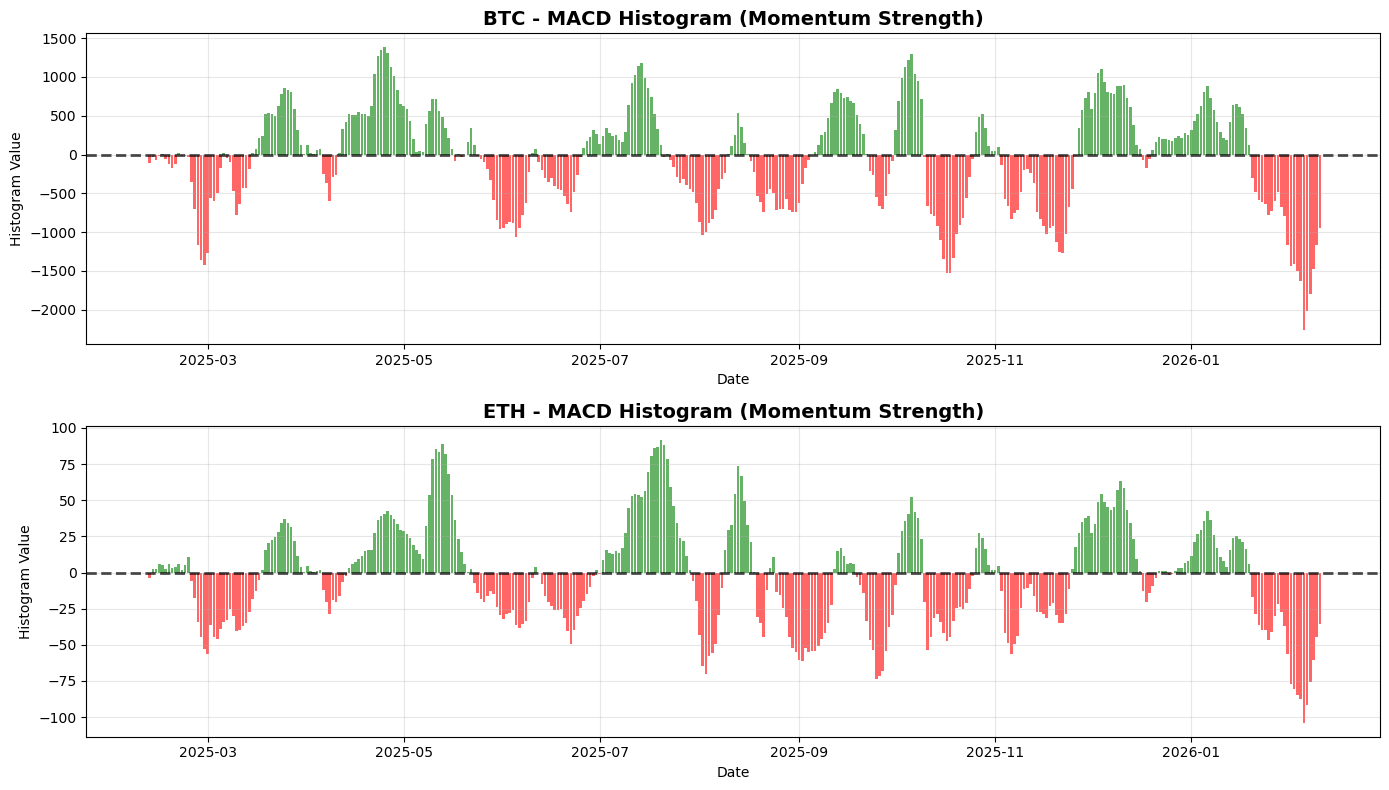

In [36]:
# Plot 2: MACD Histogram (Momentum Strength)
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for idx, coin_name in enumerate(["btc", "eth"]):
    coin_data = df[df["coin"] == coin_name].copy()
    
    ax = axes[idx]
    # Color bars: green = bullish momentum, red = bearish momentum
    colors = coin_data["macd_histogram"].apply(lambda x: "green" if x > 0 else "red")
    ax.bar(coin_data["timestamp"], coin_data["macd_histogram"], color=colors, alpha=0.6)
    ax.axhline(0, color="black", linestyle="--", linewidth=2, alpha=0.7)
    
    ax.set_title(f"{coin_name.upper()} - MACD Histogram (Momentum Strength)", fontsize=14, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Histogram Value")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

- MACD histogram peaks (Momentum Exhaustion) SignalBEFORE price bottoms/tops (leading reversal signal)
- Green bars getting taller = Bulls accelerating (buying pressure increasing)
- Peak green bar = Maximum bullish momentum ,bars start shrinking after peak = Bulls getting tired .Signal: Uptrend losing steam → Reversal down coming soon
- Red bars getting taller = Bears accelerating (selling pressure increasing) . Peak red bar = Maximum bearish momentum
Bars start shrinking after peak = Bears getting tired . Signal: Downtrend losing steam → Reversal up coming soon!


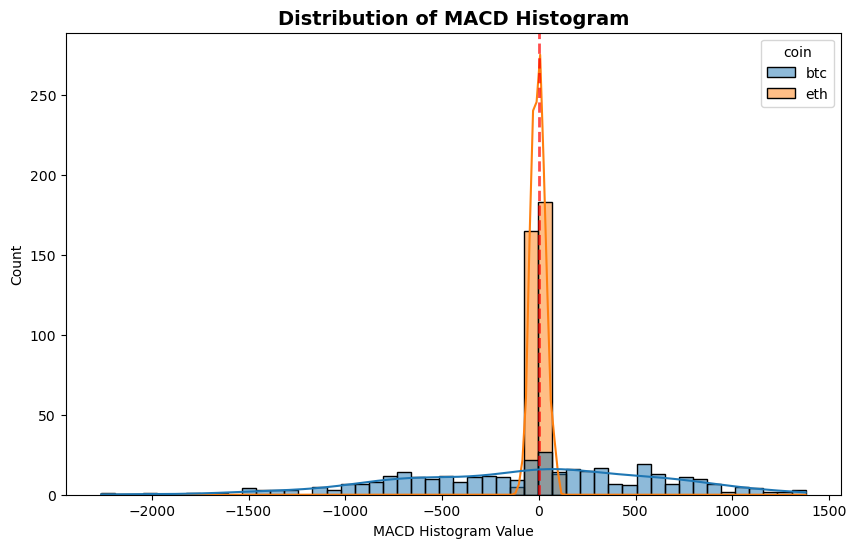

In [37]:
# Plot 3: Distribution of MACD Histogram
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.histplot(data=df, x="macd_histogram", hue="coin", bins=50, kde=True, ax=ax)
ax.set_title("Distribution of MACD Histogram", fontsize=14, fontweight="bold")
ax.set_xlabel("MACD Histogram Value")
ax.axvline(0, color="red", linestyle="--", linewidth=2, alpha=0.7)
plt.show()

1. Distribution Centered Around 0

- Mean ≈ 0 → Balanced bull/bear periods over the year ,No systematic bias in one direction .Good for ML: Model won't learn to always predict up or down

- Left tail = Extreme negative values (like -1,420 from Feb crash) ,Skewed left = More extreme bearish momentum events than bullish


## Step 6: Production ready pipeline 

* In the this file C:\Users\tlili\OneDrive\Bureau\Bootcamp\final\AI-powered-cryptocurrency-market-analysis-and-decision-support-system\src\pipeline.py  we will create a production ready pipeline that will take raw CoinGecko data, apply the previous same preprocessing and feature engineering and always output exactly our final dataset with:same columns , same order, same feature definitions .
* That will allow us later to extract row data from coingecko and use it as prediction input for our Ml /LSTM model 